## Week 10 Exercises

###<font color=green> Replace the name below with **your name**. For full credit, your total needs to add up to 100 points.

I highly recommend reading the accompanying pdf for programming notes and other important details.

# Kavin Kannan

In [149]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi,sin,cos,exp,real,imag
import scipy
from scipy.fft import fft
from numpy.fft import rfft, fftfreq
from scipy.fft import dct, idct
from scipy.io import wavfile

1. Discrete cosine transform.
(a) 5 points Define a function to calculate
fs(t) = sin(2πν1t) + cos(2πν2t)

and set ν1 = 20 kHz, ν2 = 25 kHz.
Make an array of sampling times with N = 1000 points starting at
t = 0 and with a time interval between successive points τ = 2 μs.
Plot the function fs(t) evaluated at the sampled points, vs time..
You should see a pattern of “beats” at the difference frequency
ν2 − ν1.

(b) (10 points) Apply the discrete cosine transform to your sampled
function data. Make an array of the frequencies for the discrete
cosine data – this is an array of N points with the frequency of
the k
th point equal to νk = k/(2Nτ ). Note this is a factor of two
different from νk for the discrete Fourier transform.
Plot the absolute value of the DCT data versus frequency - you
should see two clear peaks at ν1, ν2.

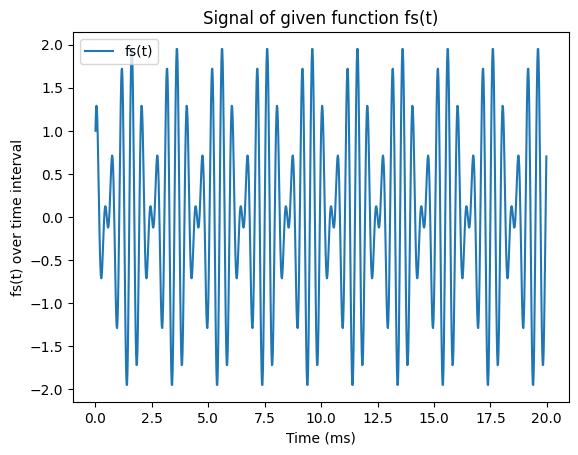

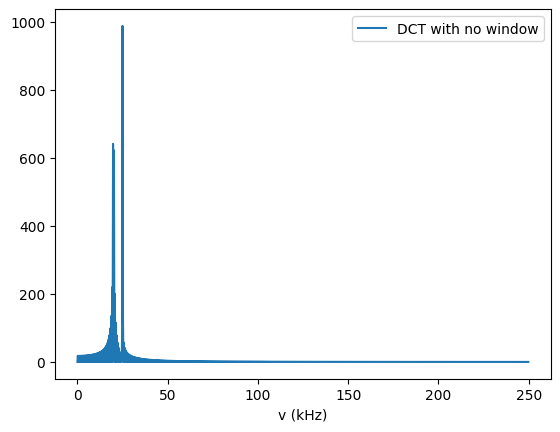

In [56]:
v1 = 20e3
v2 = 25e3
def fs(t):
    return np.sin(2*np.pi*v1*t) + np.cos(2*np.pi*v2*t)

# get data to be transformed by sampling function above
nn = 1000                          # number of points
tau = 2e-6                        # sampling time (s), here 2 microsec
t = np.linspace(0,(nn-1)*tau,nn)  # array of sample times (s)
f1 = fs(t)                      # array of sampled function points  
plt.figure()
plt.plot(t*10e3,f1,label='fs(t)')
plt.xlabel("Time (ms)")
plt.ylabel("fs(t) over time interval")
plt.title("Signal of given function fs(t)")
plt.legend()

# Compute and plot discrete FT of the data
dnu = 1/(2*nn*tau)                # frequency spacing in Hz - different by 2 from fft
nu = np.linspace(0,(nn-1)*dnu,nn) # array of frequencies (Hz)
a = dct(f1)   
plt.figure()
plt.plot(nu/10e2,abs(a),label='DCT with no window')
plt.legend()
plt.xlabel('v (kHz)')
plt.show()

2. Filtering noise.

(a) 5 points Make a new data set by adding random noise with stan-
dard deviation σ = 0.7 to the sampled fs(t) from the previous
activity. If your previous sampled data is in an array f with nn
elements, you can do this as follows:
func for normally-distributed random numbers
rng = np.random.default_rng()
f2 = f + rng.normal(0.,0.7, len(f))
Plot this new noisy sampled data verus time - the beat pattern
should be barely visible due to the noise.

(b) 5 points Apply the DCT to the noisy data - you should still see
the peaks at ν1, ν2 but now there should be random noise across
the whole frequency range. This is called “white noise”.

(c) 10 points Make a new set of transformed data that are equal to
the transformed noisy data for frequencies ν < νmax, but set to
zero for ν > νmax where νmax is a parameter you can set. This is
called filtering the data – specifically this is a “low-pass filter”.
Plot the filtered transform data for different values of νmax to see
that your code is working.

(d) 5 points Apply the inverse discrete cosine transform to your
filtered data setting νmax = 30 kHz and explain why the resulting
time-domain data appears as it does. Try shifting the cutoff to
νmax = 40 kHz, and replot the data. Which is the better upper
limit?

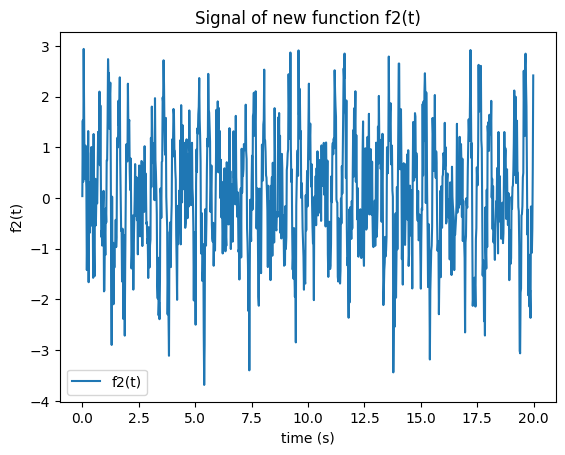

In [124]:
rng = np.random.default_rng()
f2 = f1 + rng.normal(0., 0.7,len(f1))

plt.figure()
plt.plot(t*10e3,f2,label='f2(t)')
plt.xlabel('time (s)')
plt.ylabel("f2(t)")
plt.title("Signal of new function f2(t)")
plt.legend()
plt.show()

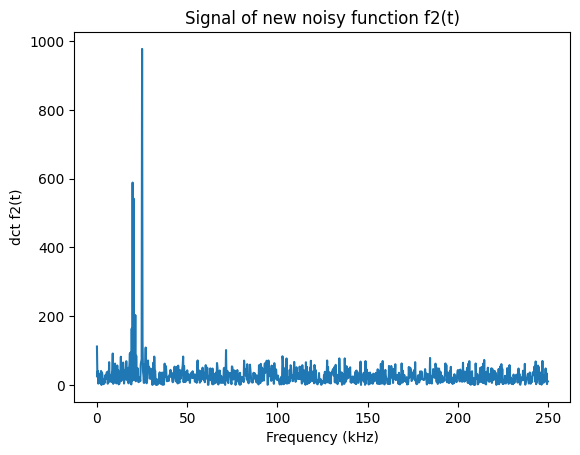

In [125]:
# Compute and plot discrete FT of the data
dnu = 1/(2*nn*tau)                # frequency spacing in Hz - different by 2 from fft
nu = np.linspace(0,(nn-1)*dnu,nn) # array of frequencies (Hz)
a = dct(f2)   
plt.plot(nu/1e3,abs(a))
plt.xlabel("Frequency (kHz)")
plt.ylabel("dct f2(t)")
plt.title("Signal of new noisy function f2(t)")
plt.show()

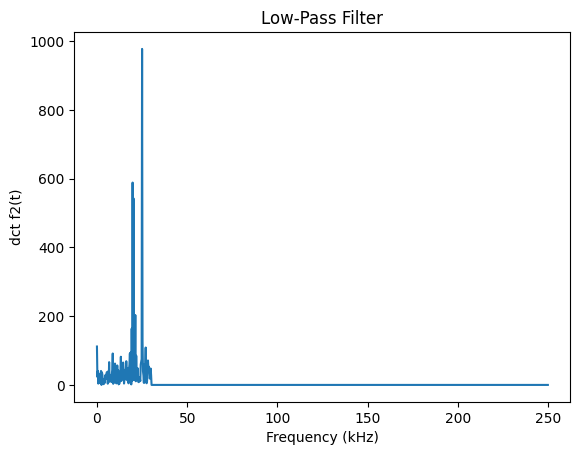

In [126]:
vmax = 30*1e3
for i in range(len(a)):
    if nu[i] > vmax:
        a[i] = 0
    else:
        a[i]=a[i]

# Compute and plot filtered discrete FT of the data
plt.plot(nu/1e3,abs(a))
plt.ylabel("dct f2(t)")
plt.xlabel("Frequency (kHz)")
plt.title("Low-Pass Filter")
plt.show()

3. Newman 7.2: Sunspots The file called sunspots.txt contains the
observed number of sunspots on the Sun for each month since January
1749. The file contains two columns of data, the first representing the
month and the second being the sunspot number.

(a) (5 points) Make a plot of the sunspots as a function of time. You
should see that the number of sunspots has fluctuated on a regular
cycle for as long as observations have been recorded. Make a rough
estimate of the length of the cycle in months.

(b) (5 points) Calculate the Fourier transform of the sunspot data and
then make a graph of the magnitude squared |ck| 2 of the Fourier
coefficients as a function of k—also called the power spectrum of
the sunspot signal. You should see that there is a noticeable peak
in the power spectrum at a nonzero value of k. The appearance of
this peak tells us that there is one frequency in the Fourier series
that has a higher amplitude than the others around it—meaning
that there is a large sine-wave term with this frequency, which
corresponds to the periodic wave you can see in the original data.

(c) (5 points) Find the approximate value of k to which the peak
corresponds. What is the period of the sine wave with this value
of k? You should find that the period corresponds roughly to the
length of the cycle that you estimated in part (a).

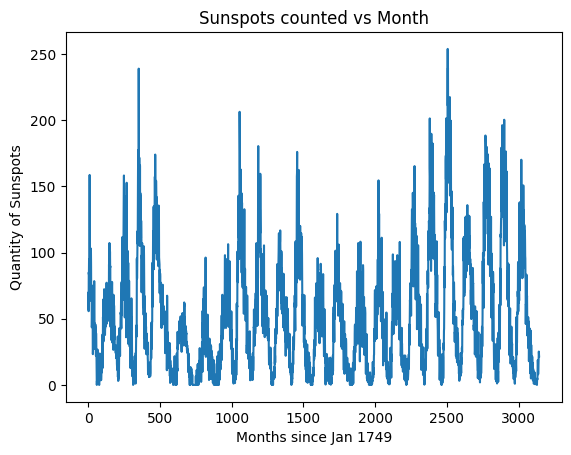

In [ ]:
sunspots = np.loadtxt("sunspots.txt")
months = sunspots[:, 0]
quantity_sunspots = sunspots[:, 1]
plt.plot(months, quantity_sunspots)
plt.xlabel("Months since Jan 1749")
plt.ylabel("Quantity of Sunspots")
plt.title("Sunspots counted vs Month")
plt.show()
# Cycle seems to take 150 months

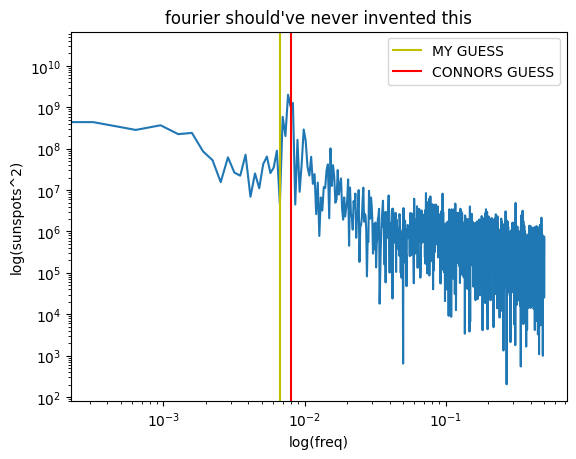

In [107]:
sunspotsFFT = scipy.fft.fft(quantity_sunspots)
sunspotsFFT_squared = np.abs(sunspotsFFT)**2
f3 = np.fft.fftfreq(len(sunspotsFFT_squared), d=1)

plt.plot(f3[:len(f3)//2], sunspotsFFT_squared[:len(f3)//2])
plt.loglog()
plt.xlabel("log(freq)")
plt.ylabel("log(sunspots^2)")
plt.axvline(1/150, color='y', label='MY GUESS')
plt.axvline(1/125, color='r', label="CONNORS GUESS")
plt.legend()
plt.title("fourier should've never invented this")
plt.show()

4. Spectral Analysis of Musical Sounds In this problem, you will
analyze tones from different instruments, and use your analysis to de-
termine the frequency of the note being played in each case. You will
then examine the Fourier spectra generated to see what gives each in-
strument its distinctive sound, or timbre.

(a) (5 points) Read in the data from the files clarinet.txt and sax-
ophone.txt. (The .txt files are constructed by taking one of the
two stereo channels of the corresponding .wav file and applying a
windowing function. ) Plot both waveforms in time. Label your
axes and title the graphs.

(b) (10 points) Use the function scipy.fft.rfft() (appropriate for real
input) to generate the discrete Fourier transform of both data
sets (you can use the function scipy.fft.rfft(), appropriate for real
input). You will note that this array is only half the length of the
original time sequence array. Explain why that is in a markdown
cell. (Hint: it has to do with the Nyquist frequency.) Next, make
an array of frequencies of length N/2 + 1, where N is the length
of the original time data, and plot the magnitude of the Fourier
coefficients from part B as a function of frequency f.


(c) (10 points) Using the subplot command with two rows and 2
columns, put the waveform plots in time in two separate plots
in the first column of your subplots, and the corresponding plots
of the Fourier coefficients as a function of frequency in the second
column. Label your axes and title the graphs.

(d) (5 points) Use your spectra to determine what note is being played
by the two instruments. (As an example, the musical note middle
C has a frequency of 261 Hz). Explain your reasoning.

(e) (5 points) Looking at your Fourier spectra for the two sounds
from Part 1, what are the main differences between the spectrum
of the clarinet vs the spectrum of the saxophone? How do you
think these differences affect the way the two instruments sound?

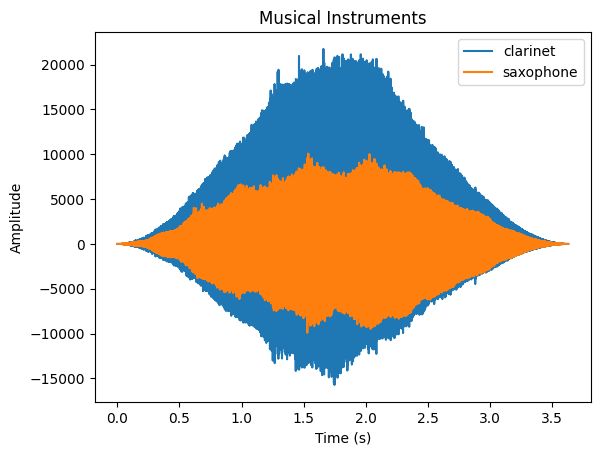

In [121]:
saxophonedata = np.loadtxt("saxophone.txt")
clarinetdata = np.loadtxt("clarinet.txt")

time = np.arange(len(clarinetdata)) / 44.1e3
plt.plot(time, clarinetdata, label = "clarinet")
plt.plot(time, saxophonedata, label = "saxophone")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.title("Musical Instruments")
plt.show()

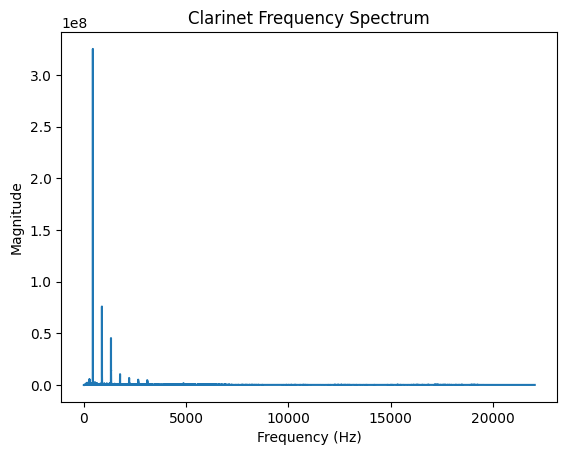

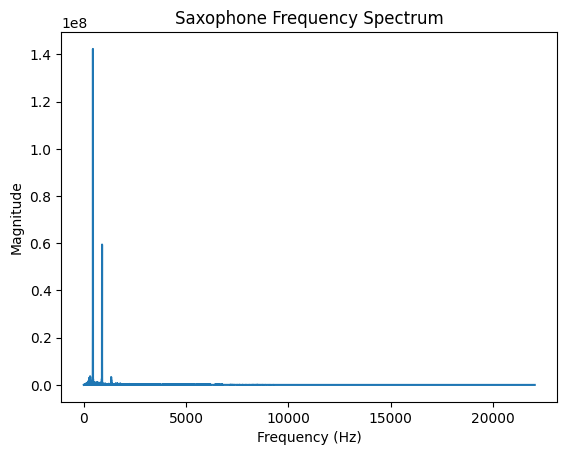

In [132]:
clarinetfft = scipy.fft.rfft(clarinetdata)
saxophonefft = scipy.fft.rfft(saxophonedata)

frequencies = np.linspace(0, 44.1e3 / 2, len(clarinetfft))

plt.plot(frequencies, np.abs(clarinetfft))
plt.title('Clarinet Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

plt.plot(frequencies, np.abs(saxophonefft))
plt.title('Saxophone Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.show()

Only half the length because we are only taking real values (not imaginary!!!)

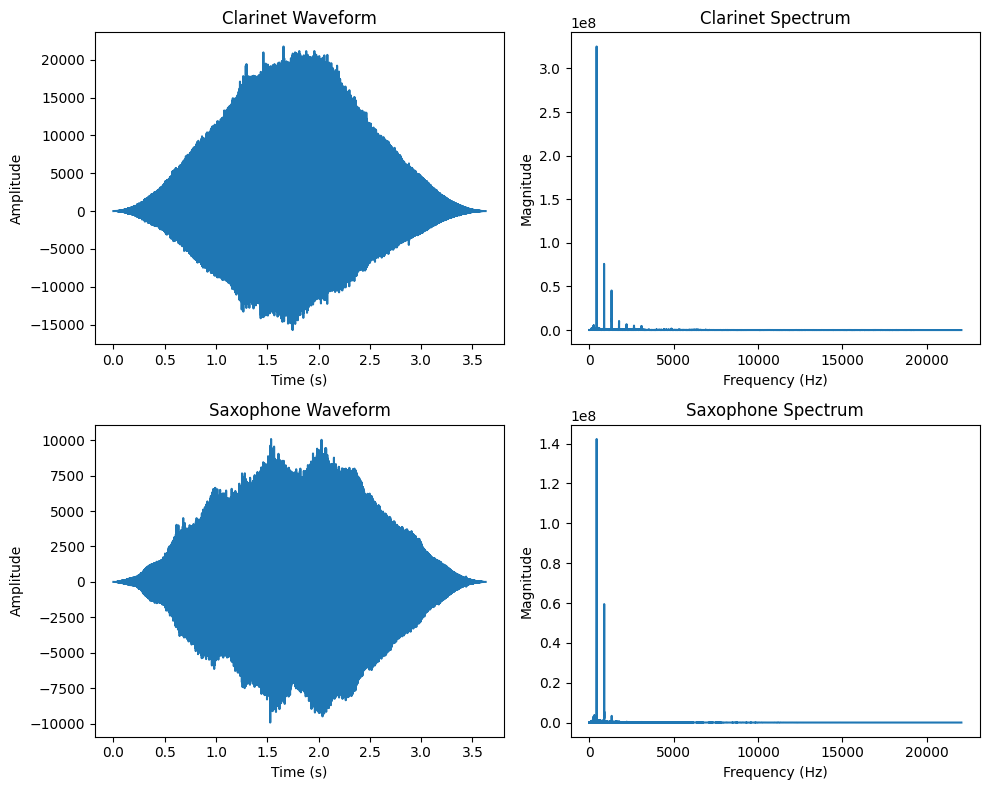

In [139]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(time, clarinetdata)
plt.title('Clarinet Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 2)
plt.plot(frequencies, np.abs(clarinetfft))
plt.title('Clarinet Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(2, 2, 3)
plt.plot(time, saxophonedata)
plt.title('Saxophone Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 4)
plt.plot(frequencies, np.abs(saxophonefft))
plt.title('Saxophone Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()

5. Analyzing of Musical Sounds Here, you will read in .wav files di-
rectly and apply a windowing function before plotting it and applying

the Fourier transform. You will need to use the commands:
rate, vwavedata = scipy.io.wavfile.read(violin_trunc.wav)
rate, cwavedata = scipy.io.wavfile.read(clarinet.wav)

(a) (10 points) Plot vwavedata, and then apply a Hanning window
(vwavedata.hanning(nn), see handout on Fourier Transforms),
where nn is the length of the data file) and plot the data again.
Do the same (raw + windowed plots) for the data from the clarinet
.wav file. Since the clarinet data are recorded in stereo, cwavedata
will be a 2-column array; plot only one of the two columns. You
may have to restrict the range of the display in order to get a clear
view of the waveforms. Show all four graphs as subplots on the
same figure.

(b) (10 points) Generate frequency arrays as you did in Part 1C, and
plot the Fourier coefficients of both violin and clarinet data. The
data for the two sounds are of different length, so you should
either generate different frequency arrays for each, or pick the
shorter of the two and slice the data accordingly. How does the
violin spectrum compare with that of the clarinet?

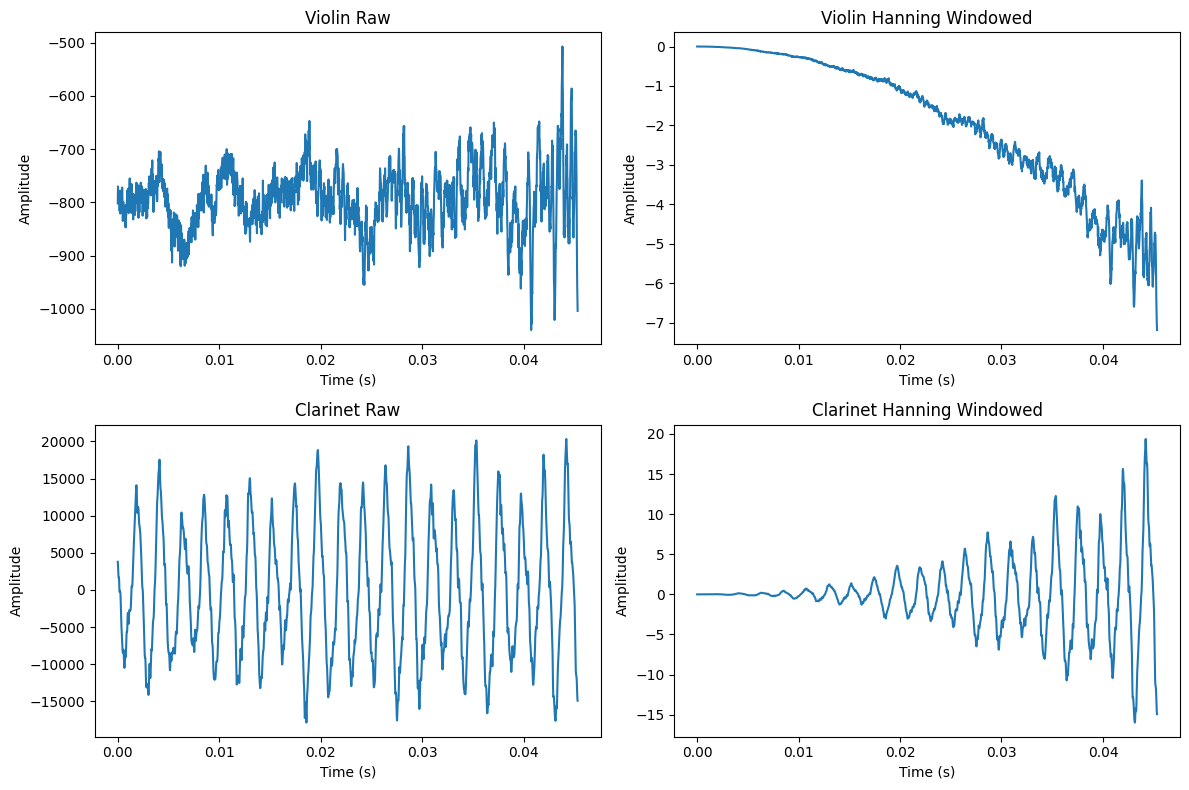

In [ ]:
rate, vwavedata = scipy.io.wavfile.read('violin_trunc.wav')
rate, cwavedata = scipy.io.wavfile.read('clarinet.wav')

cwavedata = cwavedata[:, 0]

hann_v = np.hanning(len(vwavedata))
hann_c = np.hanning(len(cwavedata))

vwavedata_hann = vwavedata * hann_v
cwavedata_hann = cwavedata * hann_c

t_v = np.linspace(0, len(vwavedata) / rate, len(vwavedata))
t_c = np.linspace(0, len(cwavedata) / rate, len(cwavedata))

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(t_v[:2000], vwavedata[:2000])
plt.title('Violin Raw')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 2)
plt.plot(t_v[:2000], vwavedata_hann[:2000])
plt.title('Violin Hanning Windowed')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 3)
plt.plot(t_c[:2000], cwavedata[:2000])
plt.title('Clarinet Raw')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 2, 4)
plt.plot(t_c[:2000], cwavedata_hann[:2000])
plt.title('Clarinet Hanning Windowed')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

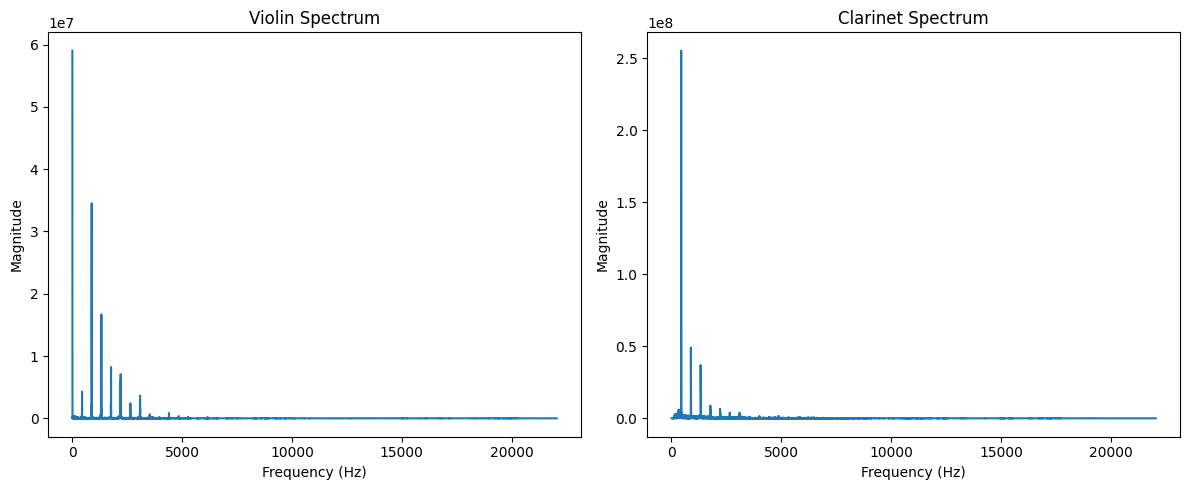

In [153]:
N = min(len(vwavedata), len(cwavedata))

vfft = rfft(vwavedata[:N])
cfft = rfft(cwavedata[:N])

freqs = np.linspace(0, rate / 2, len(vfft))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(freqs, np.abs(vfft))
plt.title('Violin Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(1, 2, 2)
plt.plot(freqs, np.abs(cfft))
plt.title('Clarinet Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.tight_layout()
plt.show()